# 01 - Rule Based Historical Frequency Baseline

This creates a simple **rule based baseline** for predicting whether an order will be delivered late.

Instead of using a Machine Learning model, we use the historical delay rate of each **Shipping Mode**.

### Basic idea

- Calculate the historical late delivery rate for each Shipping Mode using the training data.
- If the delay rate is **greater than 50%**, predict **Late (1)**.
- Otherwise, predict **On time (0)**.
- Evaluate the rule using the **validation set**.

This baseline gives us a simple performance level that later Machine Learning models should be compared against.

> **Important:** The test set is not used in this notebook. It will remain untouched until the final evaluation stage.

### Data

The notebook uses the `features_step3_*.csv` files because the original `Shipping Mode` values and actual delay rates are required for this rule.


## Setup

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

Path('../../../reports/figures').mkdir(parents=True, exist_ok=True)
Path('../../../models').mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(Path('../../../data/processed/features_step3_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/features_step3_val.csv'))

print(f"Train: {train_df.shape}, Val: {val_df.shape}")


Train: (46026, 29), Val: (7890, 29)


## 1. Build the historical delay rate lookup and apply the rule

In [12]:
shipping_mode_delay_rate = train_df.groupby('Shipping Mode')['Late_delivery_risk'].mean()
print("Shipping Mode delay rates (train):")
print(shipping_mode_delay_rate)

def apply_baseline_rule(df):
    df = df.copy()
    df['shipping_mode_delay_rate'] = df['Shipping Mode'].map(shipping_mode_delay_rate)
    df['baseline_pred'] = (df['shipping_mode_delay_rate'] > 0.5).astype(int)
    df['baseline_score'] = df['shipping_mode_delay_rate']
    return df

train_df = apply_baseline_rule(train_df)
val_df = apply_baseline_rule(val_df)

print(f"\nBaseline prediction distribution (validation):")
print(val_df['baseline_pred'].value_counts())


Shipping Mode delay rates (train):
Shipping Mode
First Class       0.955029
Same Day          0.443906
Second Class      0.768507
Standard Class    0.382626
Name: Late_delivery_risk, dtype: float64

Baseline prediction distribution (validation):
baseline_pred
0    5162
1    2728
Name: count, dtype: int64


## 2. Evaluate on the validation set

In [10]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()

    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- Rule based baseline (validation set) ---
  recall: 0.5349
  precision: 0.8391
  f1: 0.6533
  roc_auc: 0.7270
  pr_auc: 0.7429

              precision    recall  f1-score   support

 On time (0)       0.61      0.88      0.72      3611
    Late (1)       0.84      0.53      0.65      4279

    accuracy                           0.69      7890
   macro avg       0.73      0.71      0.69      7890
weighted avg       0.74      0.69      0.69      7890



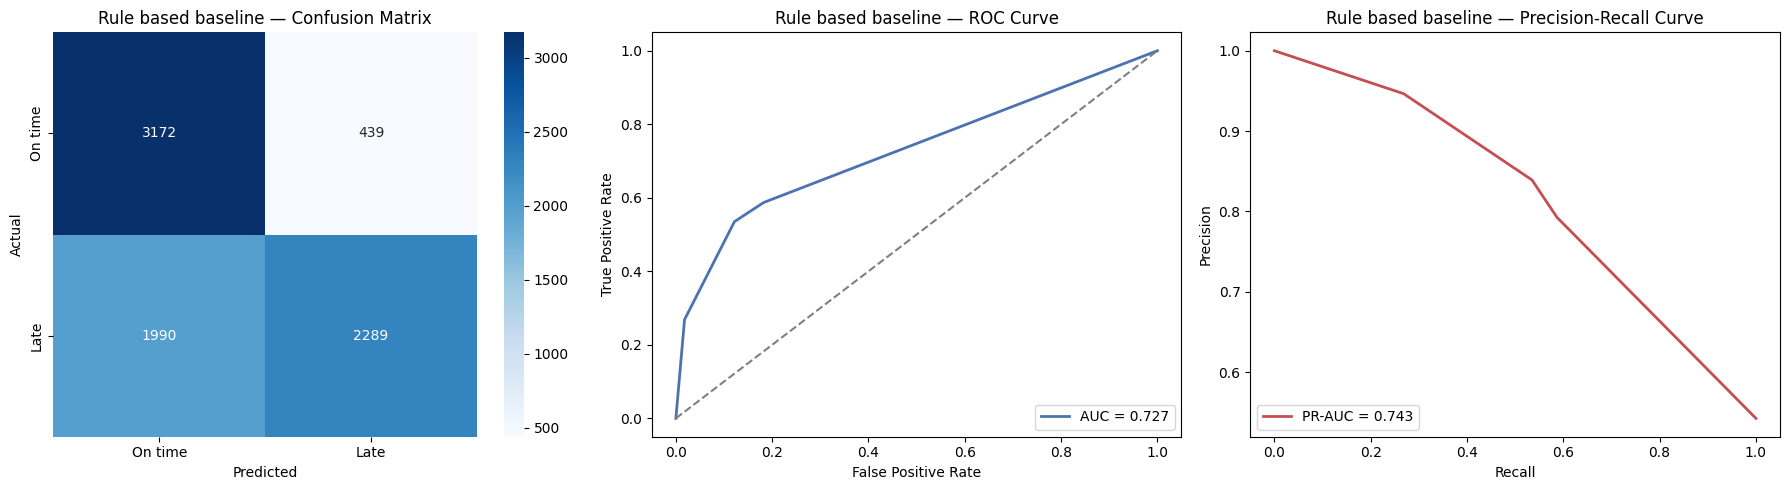

In [13]:
baseline_metrics = evaluate_and_plot(
    val_df['Late_delivery_risk'], val_df['baseline_pred'], val_df['baseline_score'],
    'Rule based baseline', save_prefix='baseline'
)


## What We Found

### Baseline Performance

The rule based baseline achieved the following results on the validation set:

- **Precision:** 0.8391
- **Recall:** 0.5349
- **F1-score:** 0.6533
- **ROC-AUC:** 0.7270
- **PR-AUC:** 0.7429
- **Accuracy:** 69%

The classification report also shows that the baseline can distinguish between the two classes:

- **On time:** Precision = 0.61, Recall = 0.88
- **Late:** Precision = 0.84, Recall = 0.53

### What This Means

The baseline uses only **Shipping Mode**, so it is a very simple prediction rule.

Its **84% precision for the Late class** means that when the rule predicts an order will be late, the prediction is correct most of the time.

However, its **53% recall** shows that the rule identifies only about half of the orders that are actually late. Some orders are late even when their Shipping Mode has an overall delay rate below 50%.

For example:

- **Same Day:** 44.4% historical delay rate
- **Standard Class:** around 38% of orders are late

Because the rule only considers Shipping Mode, it cannot account for other factors that may affect delivery delays.

### Why This Baseline Is Important

This provides a useful **baseline for the Machine Learning models**.

A more complex model should improve on this baseline, particularly by increasing **Recall** while maintaining a reasonable level of **Precision**.

The baseline therefore gives us a clear reference point for evaluating whether the additional complexity of Machine Learning provides a meaningful improvement.


## 3. Save metrics

In [15]:
save_metrics(baseline_metrics, '../../../data/processed/metrics_baseline.json')


Saved metrics to ../../../data/processed/metrics_baseline.json
